# Energy Analytics HW1 Forecasting

## Setup: Data Loading/Preparation

The cell below loads the CAISO hourly load dataset and prepares DataFrame. This is just setup and does not answer any task question directly.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

raw = pd.read_csv("data/CAISOHourlyLoadCSV(in).csv")
raw["Date"] = pd.to_datetime(raw["Date"])
raw = raw.rename(columns={"CAISO Load (MW)": "load_mw"})
raw = raw.sort_values(["Date", "Hour"]).reset_index(drop=True)
raw.head()

,Date,Hour,load_mw
0,2024-11-01,1,22523.59
1,2024-11-01,2,21909.62
2,2024-11-01,3,21835.59
3,2024-11-01,4,21205.08
4,2024-11-01,5,21129.19


### Data Summary

Below is a summary of the dataset

In [5]:
print(f"Rows: {len(raw)}")
print(f"Date range: {raw['Date'].min().date()} to {raw['Date'].max().date()}")
print(f"Hours: {raw['Hour'].min()} to {raw['Hour'].max()}")
print(f"Duplicate (Date, Hour) rows: {raw.duplicated(['Date', 'Hour']).sum()}")

Rows: 8760
Date range: 2024-11-01 to 2025-10-31
Hours: 1 to 24
Duplicate (Date, Hour) rows: 1


The data spans November 2024 through October 2025 with hours 1 through 24.

Note: there is one duplicate (Date, Hour) row from the Fall 2024 DST transition on November 3, 2024.

### Preliminary data visualization

This code plots hourly load series and monthly peaks to get idea of any patterns.

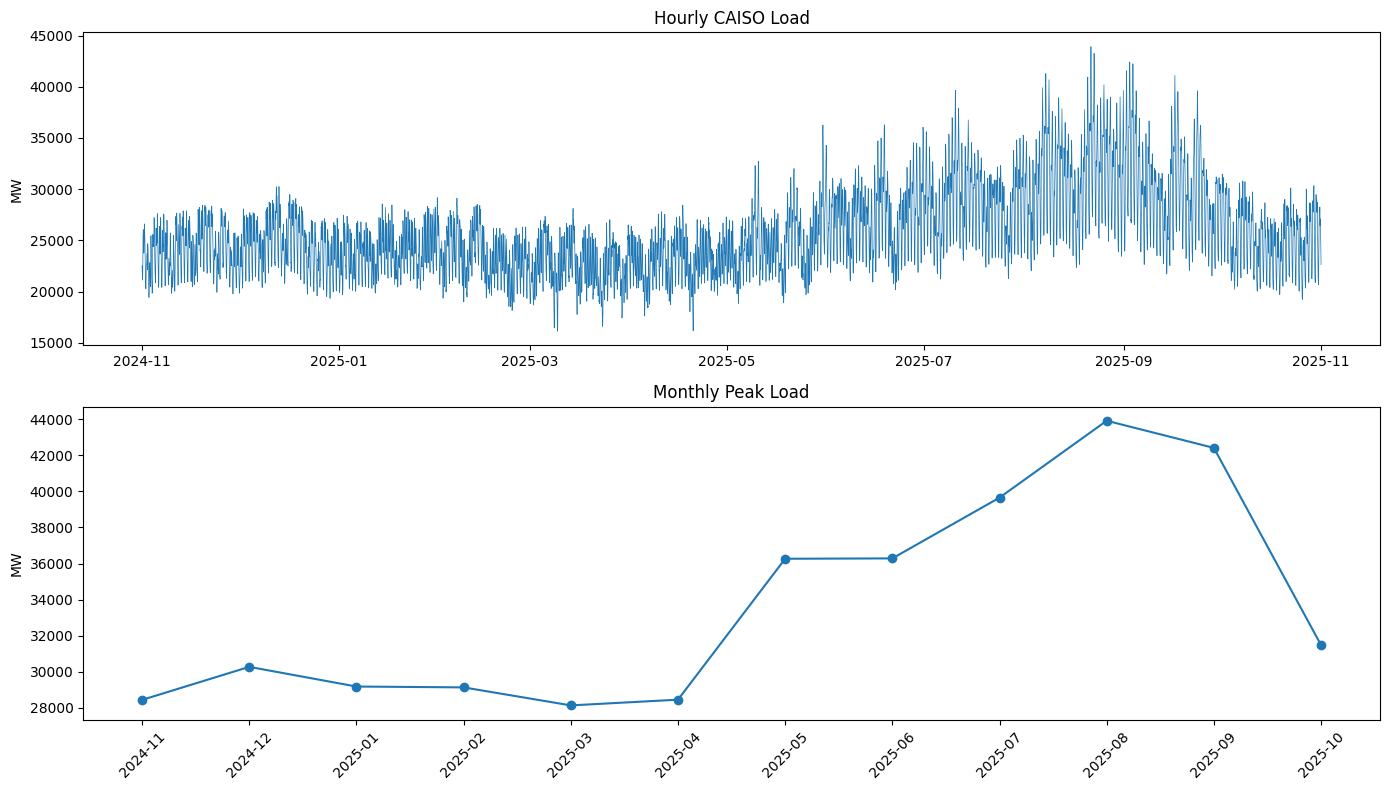

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

timestamps = raw["Date"] + pd.to_timedelta(raw["Hour"], unit="h")
axes[0].plot(timestamps, raw["load_mw"], linewidth=0.5)
axes[0].set_title("Hourly CAISO Load")
axes[0].set_ylabel("MW")

monthly_peak = raw.copy()
monthly_peak["month"] = monthly_peak["Date"].dt.to_period("M")
monthly_peak = monthly_peak.groupby("month")["load_mw"].max()

axes[1].plot(monthly_peak.index.astype(str), monthly_peak.values, marker="o")
axes[1].set_title("Monthly Peak Load")
axes[1].set_ylabel("MW")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

Load (in MW) is highest in summer (roughly July through September) and lower in spring through fall. Monthly peaks go very high, above 40,000 MW in summer but stay around 28,000 to 30,000 MW in cooler months(Nov through April).

## Task 1

First I will show Parts c and d  since the model building is what produces the Part a and b answers.

### Task 1, Part c: Analytical Journey

Here is the analytical journey I took.

Steps:
1) Converted hourly load to daily peak load in order to reduce noise. The max of daily peaks is equal to max of all hourly loads therefore this should be fine for forecasting monthly peak
2) Evaluate simple baseline model (prior month's peak as the forecast).
3) Tried several daily SARIMA models with weekly seasonality and ran rolling backtests from February 2025 through October 2025. Note: I chose to use SARIMA models instead of ARIMA models (which would typically be used for time series prediction) because SARIMA models handle seasonality much better. Given the problem, handling seasonality is important considering that electricity load likely has higher demand on weekdays instead of weekends and this likely recurring cycle should be captured in the model to make good daily forecasts.
4) Picked the SARIMA spec with the best monthly peak MAE
5) Refit on all data and forecasted daily peaks through March 2026
6) Took max forecasted daily peak in Mar 2026 as answer

#### Step 1: Baseline Model

The simplest thing to try is to predict each month's peak as equal to the prior month's peak, which is what is done here.

In [12]:
monthly_peaks = raw.copy()
monthly_peaks["month"] = monthly_peaks["Date"].dt.to_period("M")
monthly_peaks = monthly_peaks.groupby("month")["load_mw"].max()

# baseline: predict each month's peak = prior month's peak
test_months = pd.period_range("2025-02", "2025-10", freq="M")
baseline_errors = []

for m in test_months:
    actual = monthly_peaks[m]
    pred = monthly_peaks[m - 1]
    baseline_errors.append(abs(pred - actual))

baseline_mae = np.mean(baseline_errors)
baseline_mape = np.mean([baseline_errors[i] / monthly_peaks[test_months[i]] * 100 
                         for i in range(len(test_months))])
print(f"Baseline MAE: {baseline_mae:.2f} MW")
print(f"Baseline MAPE: {baseline_mape:.2f}%")

Baseline MAE: 3254.64 MW
Baseline MAPE: 9.22%


The baseline gives the MAE (mean absolute error) and MAPE (mean absolute percentage error) shown above. This model is not that good, but it serves as a starting refrence point.

#### Step 2: SARIMA Candidate Models

I fit a few SARIMA models to the daily peak series, each with weekly seasonality (s=7). For each one I ran a rolling backtest: train on everything before the month, forecast all days in that month, and take the max predicted daily peak as the monthly peak forecast. Then I compared MAE & MAPE across candidates and against the baseline.

Note on SARIMA parameters:

Each specification is written as SARIMA(p,d,q)(P,D,Q,7) where (p,d,q) capture short-term autoregressive and moving-average structure and (P,D,Q,7) capture the same effects at weekly seasonal lag (here it's 7 days). I set d = D = 0 since the daily peak series appeared stationary after aggregation. I fixed s = 7 to reflect weekly demand cycles. I tested small AR/MA orders (1–2) to capture short memory while comparing nearby candidate models for best forecasting accuracy.

In [14]:
daily_peak = raw.groupby("Date")["load_mw"].max()
daily_peak.index = pd.DatetimeIndex(daily_peak.index)
daily_peak = daily_peak.asfreq("D")

test_months = pd.period_range("2025-02", "2025-10", freq="M")

# try a few different SARIMA configs with weekly seasonality
specs = {
    "SARIMA(2,0,1)(2,0,0,7)": ((2,0,1), (2,0,0,7)),
    "SARIMA(2,0,2)(1,0,1,7)": ((2,0,2), (1,0,1,7)),
    "SARIMA(2,0,1)(1,0,1,7)": ((2,0,1), (1,0,1,7)),
}

all_results = {}

for name, (order, seasonal) in specs.items():
    month_results = []
    for m in test_months:
        train_end = m.start_time
        month_end = (m + 1).start_time
        
        train = daily_peak[daily_peak.index < train_end]
        test = daily_peak[(daily_peak.index >= train_end) & (daily_peak.index < month_end)]
        
        model = SARIMAX(train, order=order, seasonal_order=seasonal, trend="c",
                       enforce_stationarity=False, enforce_invertibility=False)
        fit = model.fit(disp=False, maxiter=300)
        pred = fit.forecast(steps=len(test))
        
        month_results.append({
            "month": str(m),
            "actual_peak": float(test.max()),
            "pred_peak": float(pred.max()),
        })
    
    df = pd.DataFrame(month_results)
    df["error"] = abs(df["pred_peak"] - df["actual_peak"])
    all_results[name] = df
    mae = df["error"].mean()
    print(f"{name}: MAE = {mae:.2f} MW")

print(f"\nBaseline: MAE = {baseline_mae:.2f} MW")

SARIMA(2,0,1)(2,0,0,7): MAE = 3827.42 MW
SARIMA(2,0,2)(1,0,1,7): MAE = 4083.25 MW
SARIMA(2,0,1)(1,0,1,7): MAE = 3761.69 MW

Baseline: MAE = 3254.64 MW


The SARIMA models have slightly higher MAE than the baseline, but the baseline can only give a single number and can't tell us which date the peak will occur on. Since we need daily forecasts to answer Part b (peak date), SARIMA is the better choice here. SARIMA(2,0,1)(1,0,1,7) has the lowest MAE of the three so going with that one.

#### Step 3: Backtest Visualization for Selected Model

Plotting actual vs predicted monthly peaks for the selected model.

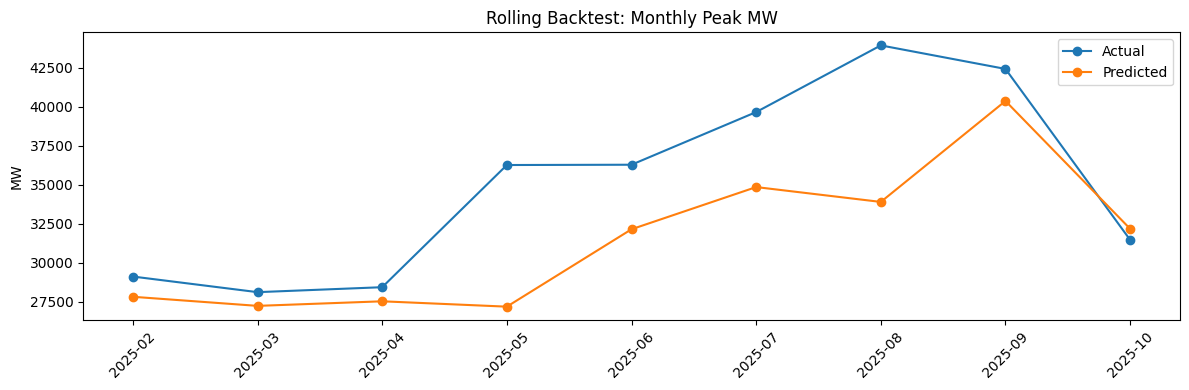

In [16]:
best = all_results["SARIMA(2,0,1)(1,0,1,7)"]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(best["month"], best["actual_peak"], marker="o", label="Actual")
ax.plot(best["month"], best["pred_peak"], marker="o", label="Predicted")
ax.set_title("Rolling Backtest: Monthly Peak MW")
ax.set_ylabel("MW")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

The model tracks the actual monthly peak reasonably well across the backtest period. The overall MAE is higher mainly because of the summer months which are harder to forecast with limited training data.

### Task 1, Part d: Final Model Specification

The final model is a SARIMA fit on daily CAISO peak load (MW), where the target series is the daily peak (max hourly load per day). The non seasonal order is (p, d, q) = (2, 0, 1) and the seasonal order is (P, D, Q, s) = (1, 0, 1, 7) to capture the weekly cycle, with a constant trend term. To produce the forecast, I forecast daily peaks from November 1, 2025 through March 31, 2026, then take the max in March 2026.

The cell below fits the model on all available data and shows the parameter estimates.

In [18]:
final_model = SARIMAX(daily_peak, order=(2,0,1), seasonal_order=(1,0,1,7), trend="c",
                      enforce_stationarity=False, enforce_invertibility=False)
final_fit = final_model.fit(disp=False, maxiter=300)

print("Parameter estimates:")
print(final_fit.params)

Parameter estimates:
intercept    2.104071e+03
ar.L1        7.247707e-01
ar.L2       -5.618166e-03
ma.L1        3.480211e-01
ar.S.L7      7.504829e-01
ma.S.L7     -3.470824e-01
sigma2       2.688901e+06
dtype: float64


Parameter estimates are shown above.

### Task 1, Parts a & b

Now use fitted model to forecast daily peaks from November 1, 2025 through March 31, 2026, pull out the March portion, and report the peak value (Part a) and its date (Part b).

In [20]:
forecast_start = daily_peak.index.max() + pd.DateOffset(days=1)
future_dates = pd.date_range(start=forecast_start, end="2026-03-31", freq="D")
forecast = pd.Series(final_fit.forecast(steps=len(future_dates)).values, index=future_dates)

march_2026 = forecast[(forecast.index.year == 2026) & (forecast.index.month == 3)]
L_star = float(march_2026.max())
d_star = march_2026.idxmax()

print(f"Part a: Forecasted peak load for March 2026: {L_star:,.2f} MW")
print(f"Part b: Forecasted peak date: {d_star.date()}")

Part a: Forecasted peak load for March 2026: 30,025.27 MW
Part b: Forecasted peak date: 2026-03-25


### Answer to Parts a & b, task 1.

Part a answer: The point forecast for March 2026 peak load is shown in the output directly above.

Part b answer: The forecasted date of the peak is shown in the output directly above.

### Task 1, Part e

As instructed, the cell below reproduces the forecast. As instructed, it does not use any data that was published/available after Feb 19, 2026,
11:59 pm PT.

In [23]:
# standalone reproducible cell for Task 1e
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

raw2 = pd.read_csv("data/CAISOHourlyLoadCSV(in).csv")
raw2["Date"] = pd.to_datetime(raw2["Date"])
raw2 = raw2.rename(columns={"CAISO Load (MW)": "load_mw"})
daily = raw2.groupby("Date")["load_mw"].max()
daily.index = pd.DatetimeIndex(daily.index)
daily = daily.asfreq("D")

mdl = SARIMAX(daily, order=(2,0,1), seasonal_order=(1,0,1,7), trend="c",
              enforce_stationarity=False, enforce_invertibility=False)
fit = mdl.fit(disp=False, maxiter=300)

start = daily.index.max() + pd.DateOffset(days=1)
idx = pd.date_range(start=start, end="2026-03-31", freq="D")
pred = pd.Series(fit.forecast(steps=len(idx)).values, index=idx)
mar = pred[(pred.index.year == 2026) & (pred.index.month == 3)]

print(f"Task 1 point forecast: {mar.max():,.2f} MW")
print(f"Task 1 peak date: {mar.idxmax().date()}")

Task 1 point forecast: 30,025.27 MW
Task 1 peak date: 2026-03-25


### Task 1, Part f

No I did not use any data in addition to the data provided by the instructor


### Task 1, Part g

All code for this assignment is located in this notebook itself. 


### Task 1, Part h
I am attaching a GitHub repo link here, which contains the larger repo with the CSV file (but this is the same CSV file which the instructor provided to students). No new code is within the repo that is not already within this notebook.

GitHub: https://github.com/vineet-reddy/hw01_energyanalytics

## Task 2

Here is how I would build a rolling monthly peak forecasting system.

First there's the data layer. Each day I would ingest hourly CAISO load, pull in weather observations and forecasts (e.g. from NOAA), and add calendar features like holidays and weekday/weekend flags. Optionally I could also pull in solar generation, storage, and EV charging data.

Next is the feature and model layer. I would build daily peak targets and explanatory features from the ingested data, then train multiple models: SARIMA for time series structure, gradient boosting (XGBoost/LightGBM) for weather and calendar effects, and quantile regression for prediction intervals. Ensembling the outputs would make it more robust.

For backtesting and monitoring, I would run rolling backtests each month on recent data, track MAE and MAPE, and retrain or swap models when performance degrades past some threshold.

Finally the operations side: on the 15th of each month, freeze data as of the prior day, produce the next month's peak forecast and expected peak date, and publish the forecast with a confidence interval and diagnostics.

The diagram below illustrates this.

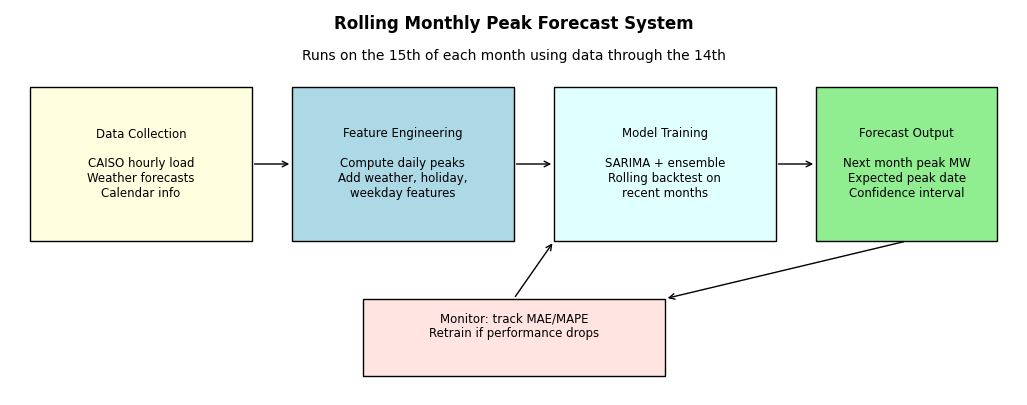

In [27]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.axis("off")

# main flow boxes with details about each stage
boxes = [
    (0.02, 0.4, 0.22, 0.4, "Data Collection\n\nCAISO hourly load\nWeather forecasts\nCalendar info", "lightyellow"),
    (0.28, 0.4, 0.22, 0.4, "Feature Engineering\n\nCompute daily peaks\nAdd weather, holiday,\nweekday features", "lightblue"),
    (0.54, 0.4, 0.22, 0.4, "Model Training\n\nSARIMA + ensemble\nRolling backtest on\nrecent months", "lightcyan"),
    (0.80, 0.4, 0.18, 0.4, "Forecast Output\n\nNext month peak MW\nExpected peak date\nConfidence interval", "lightgreen"),
]

for x, y, w, h, text, color in boxes:
    ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=color, edgecolor="black"))
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=8.5)

# arrows between boxes
for i in range(3):
    x_start = boxes[i][0] + boxes[i][2]
    x_end = boxes[i+1][0]
    ax.annotate("", xy=(x_end, 0.6), xytext=(x_start, 0.6), arrowprops=dict(arrowstyle="->"))

ax.text(0.5, 0.95, "Rolling Monthly Peak Forecast System", ha="center", fontsize=12, weight="bold")
ax.text(0.5, 0.87, "Runs on the 15th of each month using data through the 14th", ha="center", fontsize=10)

# monitoring box with feedback loop
ax.add_patch(plt.Rectangle((0.35, 0.05), 0.3, 0.2, facecolor="mistyrose", edgecolor="black"))
ax.text(0.5, 0.15, "Monitor: track MAE/MAPE\nRetrain if performance drops", ha="center", fontsize=8.5)

ax.annotate("", xy=(0.65, 0.25), xytext=(0.89, 0.4), arrowprops=dict(arrowstyle="->"))
ax.annotate("", xy=(0.54, 0.4), xytext=(0.5, 0.25), arrowprops=dict(arrowstyle="->"))

plt.show()

The diagram shows the four stage pipeline from left to right: Data Ingest, Feature Build, Model Train and Blend, and Monthly Publish and Monitor.

## Task 3: Forecasting 24 Hour Shape Factors

### Task 3, Part a

Note the following: L* is forecast of CAISO peak load in March 2026 from Task 1a. d* is the date it occurs from Task 1b. 

In order to forecast 24 shape factors s_h = L_h / L* for h = 1, ..., 24 on d* where max(L_h) = L* I would need to do the following:

First I'd take L* and d* from Task 1 and then I'd find the top 5 highest load days in March 2025 from the data. I will term these "highest load similar days" (let's call this hlds) as they all have similar peak conditions, same calendar month, and are from prior year.

For each hlds day, I'd compute the following metric: 

hourly shape = (hourly load / that day's peak)

Then, I'd average shapes across five hlds days, renormalizing so max hour has shape factor = 1.00.

Afer this, I'd forecast hourly load where d*: L_h = s_h * L* for h = 1, ..., 24.

This guarantees the max hourly load on d* equals L* wherever required.

### Task 3, Part b: If the LSE Profile Differs from the CAISO Profile

If the LSE's load profile is materially different from CAISO's, the main things that would change are the data source, the hlds day selection, and the shape model itself.

For the data source, I would use the LSE's own historical hourly load instead of CAISO system level data. For picking hlds days, I would select them based on LSE specific factors like its weather sensitivity, customer mix (residential vs commercial vs industrial), and any local calendar effects rather than just using CAISO peak days. And for the shape model, I would fit shapes to the LSE's load and normalize by the LSE's daily peak so the shape factors reflect the LSE's intraday pattern, not CAISO's.

The overall method (hlds days, averaging, renormalization) stays the same, just the inputs change to be LSE specific.

### Task 3, Part c: Extra Credit

The 24 shape factors and hourly load forecasts for d* were computed and shown below. The `shape_table` output has everything.

In [33]:
# get march 2025 data
march_2025 = raw[(raw["Date"].dt.year == 2025) & (raw["Date"].dt.month == 3)]

# find the 5 highest load similar days (hlds) in march 2025
daily_peaks_mar = march_2025.groupby("Date")["load_mw"].max().sort_values(ascending=False)
hlds_days = daily_peaks_mar.head(5).index

# compute shape factors by averaging across those days
shapes = march_2025[march_2025["Date"].isin(hlds_days)].copy()
shapes["day_peak"] = shapes.groupby("Date")["load_mw"].transform("max")
shapes["shape"] = shapes["load_mw"] / shapes["day_peak"]
avg_shape = shapes.groupby("Hour")["shape"].mean()
avg_shape = avg_shape / avg_shape.max()  # renormalize so max = 1

shape_table = pd.DataFrame({
    "Hour": avg_shape.index,
    "shape_factor": avg_shape.values,
    "forecast_load_mw": avg_shape.values * L_star
})
shape_table

,Hour,shape_factor,forecast_load_mw
0,1,0.807425,24243.141113
1,2,0.785998,23599.805525
2,3,0.765890,22996.056742
3,4,0.755653,22688.683955
4,5,0.767831,23054.326402
5,6,0.817227,24537.475648
6,7,0.892830,26807.477352
7,8,0.947908,28461.198647
8,9,0.973664,29234.536323
9,10,0.961204,28860.400965


The table above has all 24 shape factors and the forecasted hourly loads for d*. Shape factors go from about 0.77 at the lowest hours to 1.00 at the peak hour.

Plotting the shape profile below.

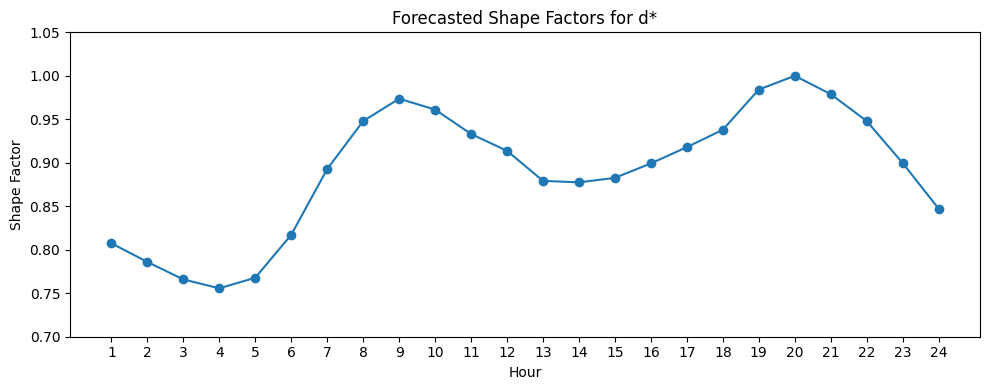

In [35]:
plt.figure(figsize=(10, 4))
plt.plot(shape_table["Hour"], shape_table["shape_factor"], marker="o")
plt.title("Forecasted Shape Factors for d*")
plt.xlabel("Hour")
plt.ylabel("Shape Factor")
plt.xticks(range(1, 25))
plt.ylim(0.7, 1.05)
plt.tight_layout()
plt.show()

The shape follows a typical intraday pattern: lower in the early morning, rising through the day to an evening peak (around Hour 20), then tapering off later at night.

## Task 4 

a) No (I did not consult with classmates or anyone else.) 

b) Not applicable. 

c) Yes 

d) I used ChatGPT 5.2. 

I used AI to help edit grammar and structure of my sentences in terms of answering questions from the problem set. I also used AI to learn and refresh concepts as well as to test my knowledge of concepts, both discrete niche ones we learned in class and more general broad ones. I also used AI to understand very general things about how to call and work with general apis for well known packages, for example statsmodels sarimax for me to be able to understand how to work with these libraries. Finally, I used AI to help me debug issues with the code when it wouldn't run properly or when would get warning or error messages. 

e) Yes, in the process of debugging the code, the AI would write code to fix the bugs, which counts as "created by anything else."

f) In various instances, I looked up official documentation for well-known libraries to remind myself of how to use them and how to use their API in my code.

https://www.statsmodels.org/dev/generated/statsmodels.tsa.statespace.sarimax.SARIMAX.html

I looked this up to understand how to use statsmodels sarimax model api and parameters.

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html

I looked this up to recall pandas groupby aggregation usage for time series preparation.

https://pandas.pydata.org/docs/reference/api/pandas.date_range.html

I looked this up to understand pandas time index creation for forecasting.

https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html

I looked this up to remember various parts of how to do matplotlib plotting.

